# Software-Engineered Chest X-Ray Analysis and Explanation System

**Notebook:** Multilabel Chest X-Ray Model Development  
**Subject:** AIMLCZG546 - Software Engineering for Machine Learning  
**Assessment:** Assignment II  
**Group:** 89

## Group Details & Contribution

| BITS ID | Name | Engineering contribution | Weight |
|---|---|---|---:|
| 2024ac05672@wilp.bits-pilani.ac.in | Ananda Vadivel D | Requirements formulation, GR4ML view preparation, quality requirement justification | 25% |
| 2024ac05968@wilp.bits-pilani.ac.in | Adurti Sai Venkatesh | Dataset preparation, exploratory data analysis, visualization support, data quality validation | 25% |
| 2024ac05653@wilp.bits-pilani.ac.in | D Mallikarjuna Reddy | ML pipeline implementation, model comparison, final evaluation, report integration | 25% |
| 2024ac05055@wilp.bits-pilani.ac.in | Krupashankar Subramani | System architecture, architectural pattern mapping, model registry artifacts, inference and application validation | 25% |

## Notebook Index

1. [Multilabel Chest X-Ray Model Development](#multilabel-chest-x-ray-model-development)
2. [1. Model Development Configuration](#1-model-development-configuration)
3. [2. Training Strategy](#2-training-strategy)
4. [3. Multilabel Input Pipeline](#3-multilabel-input-pipeline)
5. [4. Model Architecture](#4-model-architecture)
6. [5. Training and Validation Engine](#5-training-and-validation-engine)
7. [6. Training Results](#6-training-results)
8. [7. Versioned Model Packaging](#7-versioned-model-packaging)
9. [8. Model Development Readiness Gate](#8-model-development-readiness-gate)

---

The notebook records the executable implementation, retained runtime outputs, and verifiable engineering evidence for this component.


# Multilabel Chest X-Ray Model Development

This notebook develops the computer-vision foundation of the Chest X-Ray Analysis and Explanation Assistant. It implements reproducible data loading, transfer learning, imbalance-aware optimization, mixed-precision training, validation-based model selection and MLflow experiment tracking.

The resulting model predicts 14 independent target findings from a chest X-ray. Predictions are intended for research and educational demonstration and must not be interpreted as clinical diagnoses.


## 1. Model Development Configuration

The centralized path and dataset registries are loaded to establish a consistent contract for labels, image resolution, preprocessing, class weighting, model artifacts and experiment tracking.


In [1]:
from pathlib import Path
import os
import yaml

CONFIG_ROOT = (
    Path.home()
    / "chest-xray-ai-assistant"
    / "configs"
)

PATH_CONFIG_FILE = CONFIG_ROOT / "paths.yaml"
DATASET_CONFIG_FILE = (
    CONFIG_ROOT / "chestmnist_config.yaml"
)

with PATH_CONFIG_FILE.open(
    "r",
    encoding="utf-8",
) as file:
    path_config = yaml.safe_load(file)

with DATASET_CONFIG_FILE.open(
    "r",
    encoding="utf-8",
) as file:
    dataset_config = yaml.safe_load(file)

SOLUTION_ROOT = Path(path_config["solution"]["root"])
DATA_ROOT = Path(path_config["data"]["root"])
RAW_DATA_PATH = Path(path_config["data"]["raw"])
MODEL_PATH = Path(path_config["data"]["models"])
CHECKPOINT_PATH = Path(
    path_config["data"]["checkpoints"]
)
MLFLOW_PATH = Path(path_config["data"]["mlflow"])
OUTPUTS_PATH = Path(path_config["data"]["outputs"])

dataset_settings = dataset_config["dataset"]
preprocessing_settings = dataset_config["preprocessing"]

DATASET_FLAG = dataset_settings["flag"]
IMAGE_SIZE = int(dataset_settings["image_size"])
LABEL_MAP = {
    int(label_id): label_name
    for label_id, label_name
    in dataset_settings["labels"].items()
}
NUM_LABELS = len(LABEL_MAP)

print("MODEL DEVELOPMENT CONFIGURATION")
print("-" * 100)
print(f"{'Solution root':<28}: {SOLUTION_ROOT}")
print(f"{'Dataset archive':<28}: {dataset_settings['archive_path']}")
print(f"{'Image resolution':<28}: {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"{'Model input channels':<28}: {dataset_settings['model_input_channels']}")
print(f"{'Output labels':<28}: {NUM_LABELS}")
print(f"{'Model path':<28}: {MODEL_PATH}")
print(f"{'Checkpoint path':<28}: {CHECKPOINT_PATH}")
print(f"{'MLflow path':<28}: {MLFLOW_PATH}")

MODEL DEVELOPMENT CONFIGURATION
----------------------------------------------------------------------------------------------------
Solution root               : /home/jovyan/chest-xray-ai-assistant
Dataset archive             : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/raw/chestmnist_224.npz
Image resolution            : 224 × 224
Model input channels        : 3
Output labels               : 14
Model path                  : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/models
Checkpoint path             : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/checkpoints
MLflow path                 : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/mlflow


In [2]:
runtime_routes = {
    "HF_HOME": path_config["cache"]["huggingface"],
    "HF_DATASETS_CACHE": str(
        Path(path_config["cache"]["huggingface"])
        / "datasets"
    ),
    "TORCH_HOME": path_config["cache"]["torch"],
    "MLFLOW_TRACKING_URI": MLFLOW_PATH.as_uri(),
    "TOKENIZERS_PARALLELISM": "false",
}

for variable_name, variable_value in runtime_routes.items():
    os.environ[variable_name] = variable_value

MODEL_PATH.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)

print("RUNTIME ARTIFACT ROUTING")
print("-" * 100)
print(f"{'Torch model cache':<28}: {os.environ['TORCH_HOME']}")
print(f"{'MLflow tracking URI':<28}: {os.environ['MLFLOW_TRACKING_URI']}")
print(f"{'Checkpoint path':<28}: {CHECKPOINT_PATH}")

RUNTIME ARTIFACT ROUTING
----------------------------------------------------------------------------------------------------
Torch model cache           : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/models/torch-cache
MLflow tracking URI         : file:///home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/mlflow
Checkpoint path             : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/checkpoints


### 1.2 Reproducibility Controls

Randomness is controlled across the training stack so that data augmentation, parameter initialization and batch ordering remain reproducible across comparable runs.


In [3]:
import random
import numpy as np
import torch

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.set_float32_matmul_precision("high")

device = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)

print("REPRODUCIBILITY CONTROLS")
print("-" * 100)
print(f"{'Random seed':<28}: {RANDOM_SEED}")
print(f"{'Execution device':<28}: {device}")
print(f"{'cuDNN deterministic':<28}: {torch.backends.cudnn.deterministic}")
print(f"{'cuDNN benchmark':<28}: {torch.backends.cudnn.benchmark}")
print(f"{'Float32 matmul precision':<28}: {torch.get_float32_matmul_precision()}")

REPRODUCIBILITY CONTROLS
----------------------------------------------------------------------------------------------------
Random seed                 : 42
Execution device            : cuda:0
cuDNN deterministic         : True
cuDNN benchmark             : False
Float32 matmul precision    : high


## 2. Training Strategy

### 2.1 Hyperparameter Definition

The training strategy uses transfer learning with a pretrained ResNet-18 backbone. Optimization is performed with label-weighted binary cross-entropy, BF16 mixed precision, learning-rate reduction and early stopping based on validation macro ROC-AUC.


In [4]:
training_config = {
    "model_name": "resnet18",
    "pretrained_weights": "IMAGENET1K_V1",
    "batch_size": 128,
    "num_workers": 4,
    "maximum_epochs": 8,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "early_stopping_patience": 3,
    "scheduler_patience": 1,
    "scheduler_factor": 0.5,
    "mixed_precision": "bfloat16",
    "selection_metric": "validation_macro_roc_auc",
    "random_seed": RANDOM_SEED,
}

print("TRAINING HYPERPARAMETERS")
print("-" * 100)

for parameter_name, parameter_value in training_config.items():
    print(
        f"{parameter_name.replace('_', ' ').title():<34}: "
        f"{parameter_value}"
    )

TRAINING HYPERPARAMETERS
----------------------------------------------------------------------------------------------------
Model Name                        : resnet18
Pretrained Weights                : IMAGENET1K_V1
Batch Size                        : 128
Num Workers                       : 4
Maximum Epochs                    : 8
Learning Rate                     : 0.0001
Weight Decay                      : 0.0001
Early Stopping Patience           : 3
Scheduler Patience                : 1
Scheduler Factor                  : 0.5
Mixed Precision                   : bfloat16
Selection Metric                  : validation_macro_roc_auc
Random Seed                       : 42


## 3. Multilabel Input Pipeline

### 3.1 Preprocessing Pipeline Initialization

Training and evaluation transformations are initialized from the centralized dataset contract. This preserves consistency between exploratory analysis, model development and future inference services.


In [5]:
from torchvision import transforms

normalization_config = preprocessing_settings["normalization"]
augmentation_config = preprocessing_settings[
    "training_augmentation"
]

train_transform = transforms.Compose(
    [
        transforms.RandomApply(
            [
                transforms.RandomAffine(
                    degrees=augmentation_config[
                        "rotation_degrees"
                    ],
                    translate=(
                        augmentation_config[
                            "translation_fraction"
                        ],
                        augmentation_config[
                            "translation_fraction"
                        ],
                    ),
                    scale=tuple(
                        augmentation_config["scale_range"]
                    ),
                )
            ],
            p=augmentation_config[
                "affine_probability"
            ],
        ),
        transforms.RandomApply(
            [
                transforms.ColorJitter(
                    brightness=augmentation_config[
                        "brightness_variation"
                    ],
                    contrast=augmentation_config[
                        "contrast_variation"
                    ],
                )
            ],
            p=augmentation_config[
                "intensity_probability"
            ],
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=normalization_config["mean"],
            std=normalization_config[
                "standard_deviation"
            ],
        ),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=normalization_config["mean"],
            std=normalization_config[
                "standard_deviation"
            ],
        ),
    ]
)

print("PREPROCESSING PIPELINE INITIALIZATION")
print("-" * 100)
print(f"{'Training operations':<30}: {len(train_transform.transforms)}")
print(f"{'Evaluation operations':<30}: {len(evaluation_transform.transforms)}")
print(f"{'Input resolution':<30}: {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"{'Input channels':<30}: {dataset_settings['model_input_channels']}")

PREPROCESSING PIPELINE INITIALIZATION
----------------------------------------------------------------------------------------------------
Training operations           : 4
Evaluation operations         : 2
Input resolution              : 224 × 224
Input channels                : 3


### 3.2 Training Partition Initialization

The 224 × 224 training partition is initialized with memory-mapped access and controlled augmentation. Memory consumption is captured at this major loading boundary before additional image partitions are introduced.


In [6]:
import medmnist

dataset_class = getattr(
    medmnist,
    dataset_settings["name"],
)

train_dataset = dataset_class(
    split="train",
    root=str(RAW_DATA_PATH),
    size=IMAGE_SIZE,
    as_rgb=True,
    transform=train_transform,
    download=False,
    mmap_mode="r",
)

training_sample, training_target = train_dataset[0]

memory_current_file = Path(
    "/sys/fs/cgroup/memory.current"
)
training_memory_gib = (
    int(memory_current_file.read_text().strip())
    / (1024 ** 3)
)

print("TRAINING PARTITION INITIALIZATION")
print("-" * 100)
print(f"{'Training records':<30}: {len(train_dataset):,}")
print(f"{'Transformed image shape':<30}: {tuple(training_sample.shape)}")
print(f"{'Target shape':<30}: {training_target.shape}")
print(f"{'Container memory usage':<30}: {training_memory_gib:.2f} GiB")

del training_sample
del training_target

TRAINING PARTITION INITIALIZATION
----------------------------------------------------------------------------------------------------
Training records              : 78,468
Transformed image shape       : (3, 224, 224)
Target shape                  : (14,)
Container memory usage        : 16.88 GiB


In [7]:
import ctypes
import gc

del train_dataset
gc.collect()

try:
    ctypes.CDLL("libc.so.6").malloc_trim(0)
except Exception:
    pass

memory_after_release_gib = (
    int(memory_current_file.read_text().strip())
    / (1024 ** 3)
)

print("TRAINING PARTITION RELEASE")
print("-" * 100)
print(
    f"{'Container memory after release':<35}: "
    f"{memory_after_release_gib:.2f} GiB"
)
print(
    f"{'Available container memory':<35}: "
    f"{18.0 - memory_after_release_gib:.2f} GiB"
)

TRAINING PARTITION RELEASE
----------------------------------------------------------------------------------------------------
Container memory after release     : 13.20 GiB
Available container memory         : 4.80 GiB


### 3.3 Memory-Mapped Storage Planning

The compressed ChestMNIST archive cannot provide safe partition-level memory mapping in the available system memory. The archive layout and required disk capacity are therefore validated before materializing native NumPy arrays for streaming access.


In [8]:
import shutil
import zipfile

ARCHIVE_PATH = Path(
    dataset_settings["archive_path"]
)
PROCESSED_DATA_PATH = Path(
    path_config["data"]["processed"]
)
MEMMAP_DATA_PATH = (
    PROCESSED_DATA_PATH
    / f"{DATASET_FLAG}_{IMAGE_SIZE}_memmap"
)

with zipfile.ZipFile(
    ARCHIVE_PATH,
    mode="r",
) as archive:
    archive_entries = {
        entry.filename: {
            "uncompressed_bytes": entry.file_size,
            "compressed_bytes": entry.compress_size,
        }
        for entry in archive.infolist()
    }

uncompressed_gib = sum(
    entry["uncompressed_bytes"]
    for entry in archive_entries.values()
) / (1024 ** 3)

available_disk_gib = (
    shutil.disk_usage(DATA_ROOT).free
    / (1024 ** 3)
)

storage_reserve_gib = 4.0
materialization_ready = (
    available_disk_gib
    >= uncompressed_gib + storage_reserve_gib
)

print("MEMORY-MAPPED STORAGE PLANNING")
print("-" * 110)
print(f"{'Source archive':<32}: {ARCHIVE_PATH}")
print(f"{'Target directory':<32}: {MEMMAP_DATA_PATH}")
print(f"{'Archive entries':<32}: {len(archive_entries)}")
print(f"{'Uncompressed array size':<32}: {uncompressed_gib:.2f} GiB")
print(f"{'Available disk capacity':<32}: {available_disk_gib:.2f} GiB")
print(f"{'Protected storage reserve':<32}: {storage_reserve_gib:.2f} GiB")
print(
    f"{'Materialization readiness':<32}: "
    f"{'PASS' if materialization_ready else 'FAIL'}"
)

MEMORY-MAPPED STORAGE PLANNING
--------------------------------------------------------------------------------------------------------------
Source archive                  : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/raw/chestmnist_224.npz
Target directory                : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/processed/chestmnist_224_memmap
Archive entries                 : 6
Uncompressed array size         : 5.24 GiB
Available disk capacity         : 17.05 GiB
Protected storage reserve       : 4.00 GiB
Materialization readiness       : PASS


### 3.4 Memory-Mapped Array Materialization

The six official ChestMNIST arrays are materialized as native NumPy files using bounded-memory streaming. Atomic file replacement protects the processed dataset from interrupted or incomplete extraction.


In [9]:
import os
from tqdm.auto import tqdm

if not materialization_ready:
    raise RuntimeError(
        "Insufficient disk capacity for array materialization."
    )

MEMMAP_DATA_PATH.mkdir(
    parents=True,
    exist_ok=True,
)

with zipfile.ZipFile(
    ARCHIVE_PATH,
    mode="r",
) as archive:
    for entry in archive.infolist():
        target_file = (
            MEMMAP_DATA_PATH
            / Path(entry.filename).name
        )

        if (
            target_file.exists()
            and target_file.stat().st_size
            == entry.file_size
        ):
            print(
                f"Verified existing file: "
                f"{target_file.name}"
            )
            continue

        temporary_file = target_file.with_suffix(
            target_file.suffix + ".partial"
        )

        with archive.open(entry, mode="r") as source:
            with temporary_file.open("wb") as destination:
                with tqdm(
                    total=entry.file_size,
                    desc=target_file.name,
                    unit="B",
                    unit_scale=True,
                    unit_divisor=1024,
                ) as progress:
                    while True:
                        chunk = source.read(
                            16 * 1024 * 1024
                        )

                        if not chunk:
                            break

                        destination.write(chunk)
                        progress.update(len(chunk))

        os.replace(
            temporary_file,
            target_file,
        )

print("\nARRAY MATERIALIZATION COMPLETED")

train_images.npy:   0%|          | 0.00/3.67G [00:00<?, ?B/s]

train_labels.npy:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

val_images.npy:   0%|          | 0.00/537M [00:00<?, ?B/s]

val_labels.npy:   0%|          | 0.00/154k [00:00<?, ?B/s]

test_images.npy:   0%|          | 0.00/1.05G [00:00<?, ?B/s]

test_labels.npy:   0%|          | 0.00/307k [00:00<?, ?B/s]


ARRAY MATERIALIZATION COMPLETED


### 3.5 Memory-Mapped Array Validation

The materialized arrays are validated for shape, data type and true memory-mapped access. This confirms that future batches can be read from disk without loading complete image partitions into system memory.


In [10]:
expected_shapes = {
    "train_images": (
        dataset_settings["splits"]["train"],
        IMAGE_SIZE,
        IMAGE_SIZE,
    ),
    "train_labels": (
        dataset_settings["splits"]["train"],
        NUM_LABELS,
    ),
    "val_images": (
        dataset_settings["splits"]["val"],
        IMAGE_SIZE,
        IMAGE_SIZE,
    ),
    "val_labels": (
        dataset_settings["splits"]["val"],
        NUM_LABELS,
    ),
    "test_images": (
        dataset_settings["splits"]["test"],
        IMAGE_SIZE,
        IMAGE_SIZE,
    ),
    "test_labels": (
        dataset_settings["splits"]["test"],
        NUM_LABELS,
    ),
}

memmap_validation = {}

print("MEMORY-MAPPED ARRAY VALIDATION")
print("-" * 115)
print(
    f"{'Array':<20}"
    f"{'Shape':>25}"
    f"{'Data type':>15}"
    f"{'Memory mapped':>18}"
    f"{'Status':>12}"
)
print("-" * 115)

for array_name, expected_shape in expected_shapes.items():
    array_path = (
        MEMMAP_DATA_PATH
        / f"{array_name}.npy"
    )

    mapped_array = np.load(
        array_path,
        mmap_mode="r",
        allow_pickle=False,
    )

    is_valid = (
        mapped_array.shape == expected_shape
        and isinstance(mapped_array, np.memmap)
    )

    memmap_validation[array_name] = is_valid

    print(
        f"{array_name:<20}"
        f"{str(mapped_array.shape):>25}"
        f"{str(mapped_array.dtype):>15}"
        f"{str(isinstance(mapped_array, np.memmap)):>18}"
        f"{'PASS' if is_valid else 'FAIL':>12}"
    )

    del mapped_array

page_size = os.sysconf("SC_PAGE_SIZE")
resident_pages = int(
    Path("/proc/self/statm")
    .read_text()
    .split()[1]
)
process_rss_gib = (
    resident_pages * page_size / (1024 ** 3)
)

print("-" * 115)
print(
    f"Process resident memory: {process_rss_gib:.2f} GiB"
)
print(
    "OVERALL STATUS: "
    + (
        "PASS"
        if all(memmap_validation.values())
        else "FAIL"
    )
)

MEMORY-MAPPED ARRAY VALIDATION
-------------------------------------------------------------------------------------------------------------------
Array                                   Shape      Data type     Memory mapped      Status
-------------------------------------------------------------------------------------------------------------------
train_images                (78468, 224, 224)          uint8              True        PASS
train_labels                      (78468, 14)          uint8              True        PASS
val_images                  (11219, 224, 224)          uint8              True        PASS
val_labels                        (11219, 14)          uint8              True        PASS
test_images                 (22433, 224, 224)          uint8              True        PASS
test_labels                       (22433, 14)          uint8              True        PASS
----------------------------------------------------------------------------------------------------

### 3.6 Memory-Mapped Dataset Interface

A custom PyTorch dataset provides batch-level access to the memory-mapped ChestMNIST arrays. Images are converted to RGB only when requested, and source indices are retained to support prediction auditing and explainability.


In [11]:
from PIL import Image
from torch.utils.data import Dataset

class ChestMNISTMemmapDataset(Dataset):
    """Memory-efficient ChestMNIST dataset."""

    valid_splits = {"train", "val", "test"}

    def __init__(
        self,
        data_root,
        split,
        transform=None,
    ):
        if split not in self.valid_splits:
            raise ValueError(
                f"Unsupported split: {split}"
            )

        self.data_root = Path(data_root)
        self.split = split
        self.transform = transform

        self.images = np.load(
            self.data_root
            / f"{split}_images.npy",
            mmap_mode="r",
            allow_pickle=False,
        )

        self.labels = np.load(
            self.data_root
            / f"{split}_labels.npy",
            mmap_mode="r",
            allow_pickle=False,
        )

        if len(self.images) != len(self.labels):
            raise ValueError(
                f"Image-label count mismatch for {split}"
            )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = Image.fromarray(
            self.images[index],
            mode="L",
        ).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        target = torch.tensor(
            self.labels[index],
            dtype=torch.float32,
        )

        return image, target, int(index)


print("ChestMNISTMemmapDataset interface created.")

ChestMNISTMemmapDataset interface created.


### 3.7 Training and Validation Dataset Initialization

The memory-mapped training and validation datasets are initialized with their respective transformation pipelines. The test partition is intentionally excluded from model development to preserve unbiased final evaluation.


In [12]:
train_dataset = ChestMNISTMemmapDataset(
    data_root=MEMMAP_DATA_PATH,
    split="train",
    transform=train_transform,
)

validation_dataset = ChestMNISTMemmapDataset(
    data_root=MEMMAP_DATA_PATH,
    split="val",
    transform=evaluation_transform,
)

sample_image, sample_target, sample_index = (
    train_dataset[0]
)

resident_pages = int(
    Path("/proc/self/statm")
    .read_text()
    .split()[1]
)
dataset_rss_gib = (
    resident_pages
    * os.sysconf("SC_PAGE_SIZE")
    / (1024 ** 3)
)

print("TRAINING AND VALIDATION DATASETS")
print("-" * 100)
print(f"{'Training records':<30}: {len(train_dataset):,}")
print(f"{'Validation records':<30}: {len(validation_dataset):,}")
print(f"{'Sample image shape':<30}: {tuple(sample_image.shape)}")
print(f"{'Sample target shape':<30}: {tuple(sample_target.shape)}")
print(f"{'Sample target dtype':<30}: {sample_target.dtype}")
print(f"{'Sample source index':<30}: {sample_index}")
print(f"{'Process resident memory':<30}: {dataset_rss_gib:.2f} GiB")

del sample_image
del sample_target

TRAINING AND VALIDATION DATASETS
----------------------------------------------------------------------------------------------------
Training records              : 78,468
Validation records            : 11,219
Sample image shape            : (3, 224, 224)
Sample target shape           : (14,)
Sample target dtype           : torch.float32
Sample source index           : 0
Process resident memory       : 0.63 GiB


### 3.8 Reproducible Batch Loaders

Reproducible PyTorch data loaders are created for shuffled training batches and deterministic validation batches. Worker count is constrained to the container CPU allocation, while pinned memory supports asynchronous GPU transfer.


In [13]:
from torch.utils.data import DataLoader

def seed_data_worker(worker_id):
    worker_seed = (
        torch.initial_seed() % (2 ** 32)
    )
    np.random.seed(worker_seed)
    random.seed(worker_seed)


loader_generator = torch.Generator()
loader_generator.manual_seed(RANDOM_SEED)

loader_settings = {
    "batch_size": training_config["batch_size"],
    "num_workers": training_config["num_workers"],
    "pin_memory": True,
    "persistent_workers": (
        training_config["num_workers"] > 0
    ),
    "worker_init_fn": seed_data_worker,
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=loader_generator,
    **loader_settings,
)

validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **loader_settings,
)

print("REPRODUCIBLE BATCH LOADERS")
print("-" * 100)
print(f"{'Training batches':<30}: {len(train_loader):,}")
print(f"{'Validation batches':<30}: {len(validation_loader):,}")
print(f"{'Batch size':<30}: {loader_settings['batch_size']}")
print(f"{'Worker processes':<30}: {loader_settings['num_workers']}")
print(f"{'Pinned memory':<30}: {loader_settings['pin_memory']}")
print(f"{'Persistent workers':<30}: {loader_settings['persistent_workers']}")

REPRODUCIBLE BATCH LOADERS
----------------------------------------------------------------------------------------------------
Training batches              : 614
Validation batches            : 88
Batch size                    : 128
Worker processes              : 4
Pinned memory                 : True
Persistent workers            : True


### 3.9 Batch Transfer Smoke Test

A single batch is loaded and transferred to the GPU to verify the complete input path from memory-mapped storage through preprocessing, multiprocessing collation and device transfer.


In [14]:
import time

batch_start = time.perf_counter()

batch_images, batch_targets, batch_indices = next(
    iter(train_loader)
)

batch_images_gpu = batch_images.to(
    device,
    non_blocking=True,
)
batch_targets_gpu = batch_targets.to(
    device,
    non_blocking=True,
)

torch.cuda.synchronize()
batch_elapsed_ms = (
    time.perf_counter() - batch_start
) * 1000

container_memory_gib = (
    int(memory_current_file.read_text().strip())
    / (1024 ** 3)
)
gpu_memory_gib = (
    torch.cuda.memory_allocated()
    / (1024 ** 3)
)

print("BATCH TRANSFER SMOKE TEST")
print("-" * 100)
print(f"{'Image batch shape':<30}: {tuple(batch_images.shape)}")
print(f"{'Target batch shape':<30}: {tuple(batch_targets.shape)}")
print(f"{'Index batch shape':<30}: {tuple(batch_indices.shape)}")
print(f"{'Image device':<30}: {batch_images_gpu.device}")
print(f"{'Target data type':<30}: {batch_targets_gpu.dtype}")
print(f"{'Target values':<30}: {torch.unique(batch_targets_gpu).tolist()}")
print(f"{'Batch preparation time':<30}: {batch_elapsed_ms:.2f} ms")
print(f"{'Container memory usage':<30}: {container_memory_gib:.2f} GiB")
print(f"{'GPU tensor memory':<30}: {gpu_memory_gib:.2f} GiB")

del batch_images
del batch_targets
del batch_indices
del batch_images_gpu
del batch_targets_gpu

torch.cuda.empty_cache()

BATCH TRANSFER SMOKE TEST
----------------------------------------------------------------------------------------------------
Image batch shape             : (128, 3, 224, 224)
Target batch shape            : (128, 14)
Index batch shape             : (128,)
Image device                  : cuda:0
Target data type              : torch.float32
Target values                 : [0.0, 1.0]
Batch preparation time        : 1671.68 ms
Container memory usage        : 18.00 GiB
GPU tensor memory             : 0.07 GiB


In [15]:
memory_stat_file = Path(
    "/sys/fs/cgroup/memory.stat"
)

memory_stats = {}

for line in memory_stat_file.read_text().splitlines():
    key, value = line.split()
    memory_stats[key] = int(value)

memory_components = {
    "Anonymous process memory": memory_stats.get("anon", 0),
    "Filesystem cache": memory_stats.get("file", 0),
    "Shared memory": memory_stats.get("shmem", 0),
    "Kernel slab memory": (
        memory_stats.get("slab", 0)
    ),
    "Page tables": memory_stats.get("pagetables", 0),
}

print("CONTAINER MEMORY COMPOSITION")
print("-" * 100)

for component_name, component_bytes in memory_components.items():
    print(
        f"{component_name:<32}: "
        f"{component_bytes / (1024 ** 3):.2f} GiB"
    )

CONTAINER MEMORY COMPOSITION
----------------------------------------------------------------------------------------------------
Anonymous process memory        : 5.75 GiB
Filesystem cache                : 11.72 GiB
Shared memory                   : 1.03 GiB
Kernel slab memory              : 0.42 GiB
Page tables                     : 0.03 GiB


## 4. Model Architecture

### 4.1 Pretrained ResNet-18 Initialization

An ImageNet-pretrained ResNet-18 is adapted for ChestMNIST by replacing its original classification layer with a dropout-regularized 14-output head. Each output represents an independent finding logit.


In [16]:
import torch.nn as nn
from torchvision.models import (
    ResNet18_Weights,
    resnet18,
)

CLASSIFIER_DROPOUT = 0.20
training_config["classifier_dropout"] = (
    CLASSIFIER_DROPOUT
)

pretrained_weights = (
    ResNet18_Weights.IMAGENET1K_V1
)

model = resnet18(
    weights=pretrained_weights,
)

classifier_input_features = (
    model.fc.in_features
)

model.fc = nn.Sequential(
    nn.Dropout(
        p=CLASSIFIER_DROPOUT,
    ),
    nn.Linear(
        classifier_input_features,
        NUM_LABELS,
    ),
)

model = model.to(device)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("RESNET-18 MODEL INITIALIZATION")
print("-" * 100)
print(f"{'Pretrained weights':<30}: {pretrained_weights}")
print(f"{'Classifier input features':<30}: {classifier_input_features}")
print(f"{'Output logits':<30}: {NUM_LABELS}")
print(f"{'Classifier dropout':<30}: {CLASSIFIER_DROPOUT}")
print(f"{'Total parameters':<30}: {total_parameters:,}")
print(f"{'Trainable parameters':<30}: {trainable_parameters:,}")
print(f"{'Execution device':<30}: {next(model.parameters()).device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/models/torch-cache/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 66.1MB/s]


RESNET-18 MODEL INITIALIZATION
----------------------------------------------------------------------------------------------------
Pretrained weights            : ResNet18_Weights.IMAGENET1K_V1
Classifier input features     : 512
Output logits                 : 14
Classifier dropout            : 0.2
Total parameters              : 11,183,694
Trainable parameters          : 11,183,694
Execution device              : cuda:0


### 4.2 Loss and Optimization Components

Imbalance-aware binary cross-entropy is configured for the 14 independent outputs. AdamW optimization, validation-driven learning-rate reduction and gradient clipping provide stable full-model fine-tuning.


In [17]:
positive_weight_config = dataset_config[
    "class_imbalance"
]["positive_weights"]

positive_weight_tensor = torch.tensor(
    [
        positive_weight_config[
            LABEL_MAP[label_id]
        ]
        for label_id in range(NUM_LABELS)
    ],
    dtype=torch.float32,
    device=device,
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight_tensor,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=training_config["learning_rate"],
    weight_decay=training_config["weight_decay"],
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=training_config["scheduler_factor"],
    patience=training_config["scheduler_patience"],
)

GRADIENT_CLIP_NORM = 1.0
training_config["gradient_clip_norm"] = (
    GRADIENT_CLIP_NORM
)

autocast_dtype = torch.bfloat16

print("LOSS AND OPTIMIZATION COMPONENTS")
print("-" * 100)
print(f"{'Loss function':<30}: BCEWithLogitsLoss")
print(f"{'Positive-weight shape':<30}: {tuple(positive_weight_tensor.shape)}")
print(f"{'Minimum positive weight':<30}: {positive_weight_tensor.min().item():.2f}")
print(f"{'Maximum positive weight':<30}: {positive_weight_tensor.max().item():.2f}")
print(f"{'Optimizer':<30}: AdamW")
print(f"{'Initial learning rate':<30}: {optimizer.param_groups[0]['lr']}")
print(f"{'Gradient clip norm':<30}: {GRADIENT_CLIP_NORM}")
print(f"{'Mixed-precision dtype':<30}: {autocast_dtype}")

LOSS AND OPTIMIZATION COMPONENTS
----------------------------------------------------------------------------------------------------
Loss function                 : BCEWithLogitsLoss
Positive-weight shape         : (14,)
Minimum positive weight       : 4.64
Maximum positive weight       : 100.00
Optimizer                     : AdamW
Initial learning rate         : 0.0001
Gradient clip norm            : 1.0
Mixed-precision dtype         : torch.bfloat16


### 4.3 Forward and Backward Pass Smoke Test

A single controlled batch is passed through the full optimization path before sustained training begins. The test confirms output dimensions, numerical stability, gradient flow and GPU-memory suitability.


In [18]:
model.train()
optimizer.zero_grad(set_to_none=True)
torch.cuda.reset_peak_memory_stats()

smoke_images, smoke_targets, _ = next(
    iter(train_loader)
)

smoke_images = smoke_images.to(
    device,
    non_blocking=True,
)
smoke_targets = smoke_targets.to(
    device,
    non_blocking=True,
)

with torch.amp.autocast(
    device_type="cuda",
    dtype=autocast_dtype,
):
    smoke_logits = model(smoke_images)
    smoke_loss = criterion(
        smoke_logits,
        smoke_targets,
    )

smoke_loss.backward()

gradient_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=GRADIENT_CLIP_NORM,
)

peak_gpu_memory_gib = (
    torch.cuda.max_memory_allocated()
    / (1024 ** 3)
)

print("FORWARD AND BACKWARD PASS SMOKE TEST")
print("-" * 100)
print(f"{'Input batch shape':<30}: {tuple(smoke_images.shape)}")
print(f"{'Output logits shape':<30}: {tuple(smoke_logits.shape)}")
print(f"{'Loss value':<30}: {smoke_loss.item():.6f}")
print(f"{'Finite loss':<30}: {torch.isfinite(smoke_loss).item()}")
print(f"{'Gradient norm':<30}: {float(gradient_norm):.4f}")
print(f"{'Peak GPU memory':<30}: {peak_gpu_memory_gib:.2f} GiB")

optimizer.zero_grad(set_to_none=True)

del smoke_images
del smoke_targets
del smoke_logits
del smoke_loss

torch.cuda.empty_cache()

FORWARD AND BACKWARD PASS SMOKE TEST
----------------------------------------------------------------------------------------------------
Input batch shape             : (128, 3, 224, 224)
Output logits shape           : (128, 14)
Loss value                    : 1.296862
Finite loss                   : True
Gradient norm                 : 3.8161
Peak GPU memory               : 1.61 GiB


## 5. Training and Validation Engine

### 5.1 Multilabel Metric Utility

A reusable metric utility calculates macro and micro ROC-AUC, average precision, F1-score and Hamming loss. The initial decision threshold is 0.50; finding-specific thresholds will be calibrated after model selection.


In [19]:
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    hamming_loss,
    roc_auc_score,
)

def calculate_multilabel_metrics(
    targets,
    probabilities,
    threshold=0.50,
):
    predictions = (
        probabilities >= threshold
    ).astype(np.uint8)

    return {
        "macro_roc_auc": float(
            roc_auc_score(
                targets,
                probabilities,
                average="macro",
            )
        ),
        "micro_roc_auc": float(
            roc_auc_score(
                targets,
                probabilities,
                average="micro",
            )
        ),
        "macro_average_precision": float(
            average_precision_score(
                targets,
                probabilities,
                average="macro",
            )
        ),
        "micro_average_precision": float(
            average_precision_score(
                targets,
                probabilities,
                average="micro",
            )
        ),
        "macro_f1": float(
            f1_score(
                targets,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "micro_f1": float(
            f1_score(
                targets,
                predictions,
                average="micro",
                zero_division=0,
            )
        ),
        "hamming_loss": float(
            hamming_loss(
                targets,
                predictions,
            )
        ),
    }


print("Multilabel metric utility created.")

Multilabel metric utility created.


### 5.2 Single-Epoch Training Function

A reusable training function executes BF16 forward propagation, weighted-loss calculation, backpropagation, gradient clipping and optimizer updates for one epoch.


In [20]:
from tqdm.auto import tqdm

def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device,
    autocast_dtype,
    gradient_clip_norm,
    epoch_number,
):
    model.train()

    cumulative_loss = 0.0
    processed_samples = 0

    torch.cuda.synchronize()
    epoch_start = time.perf_counter()

    progress_bar = tqdm(
        data_loader,
        desc=f"Training epoch {epoch_number}",
        leave=False,
    )

    for images, targets, _ in progress_bar:
        images = images.to(
            device,
            non_blocking=True,
        )
        targets = targets.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            dtype=autocast_dtype,
        ):
            logits = model(images)
            loss = criterion(logits, targets)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=gradient_clip_norm,
        )

        optimizer.step()

        batch_size = images.size(0)
        cumulative_loss += (
            loss.item() * batch_size
        )
        processed_samples += batch_size

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    torch.cuda.synchronize()
    elapsed_seconds = (
        time.perf_counter() - epoch_start
    )

    return {
        "loss": (
            cumulative_loss / processed_samples
        ),
        "samples": processed_samples,
        "duration_seconds": elapsed_seconds,
        "samples_per_second": (
            processed_samples / elapsed_seconds
        ),
    }


print("Single-epoch training function created.")

Single-epoch training function created.


### 5.3 Validation Function

A reusable validation function performs deterministic inference, aggregates sigmoid probabilities and calculates the complete multilabel metric set without updating model parameters.


In [21]:
def validate_model(
    model,
    data_loader,
    criterion,
    device,
    autocast_dtype,
    epoch_number,
):
    model.eval()

    cumulative_loss = 0.0
    processed_samples = 0

    target_batches = []
    probability_batches = []
    index_batches = []

    torch.cuda.synchronize()
    validation_start = time.perf_counter()

    progress_bar = tqdm(
        data_loader,
        desc=f"Validation epoch {epoch_number}",
        leave=False,
    )

    with torch.no_grad():
        for images, targets, indices in progress_bar:
            images = images.to(
                device,
                non_blocking=True,
            )
            targets = targets.to(
                device,
                non_blocking=True,
            )

            with torch.amp.autocast(
                device_type="cuda",
                dtype=autocast_dtype,
            ):
                logits = model(images)
                loss = criterion(logits, targets)

            probabilities = torch.sigmoid(
                logits
            )

            batch_size = images.size(0)
            cumulative_loss += (
                loss.item() * batch_size
            )
            processed_samples += batch_size

            target_batches.append(
                targets.cpu().numpy()
            )
            probability_batches.append(
                probabilities.float().cpu().numpy()
            )
            index_batches.append(
                indices.numpy()
            )

    torch.cuda.synchronize()
    elapsed_seconds = (
        time.perf_counter() - validation_start
    )

    validation_targets = np.concatenate(
        target_batches,
        axis=0,
    )
    validation_probabilities = np.concatenate(
        probability_batches,
        axis=0,
    )
    validation_indices = np.concatenate(
        index_batches,
        axis=0,
    )

    validation_metrics = calculate_multilabel_metrics(
        validation_targets,
        validation_probabilities,
        threshold=0.50,
    )

    return {
        "loss": (
            cumulative_loss / processed_samples
        ),
        "samples": processed_samples,
        "duration_seconds": elapsed_seconds,
        "samples_per_second": (
            processed_samples / elapsed_seconds
        ),
        "metrics": validation_metrics,
        "targets": validation_targets,
        "probabilities": validation_probabilities,
        "indices": validation_indices,
    }


print("Validation function created.")

Validation function created.


### 5.4 Checkpoint and Early-Stopping Controller

Validation macro ROC-AUC governs model selection. Each improvement produces a versioned checkpoint containing the model, optimizer, scheduler, configuration and label contract required to resume or reproduce training.


In [22]:
BEST_CHECKPOINT_FILE = (
    CHECKPOINT_PATH
    / "resnet18_chestmnist_best.pt"
)

class ModelCheckpointController:
    def __init__(
        self,
        checkpoint_file,
        patience,
        minimum_improvement=1e-4,
    ):
        self.checkpoint_file = Path(
            checkpoint_file
        )
        self.patience = patience
        self.minimum_improvement = (
            minimum_improvement
        )

        self.best_metric = float("-inf")
        self.best_epoch = 0
        self.epochs_without_improvement = 0

    def update(
        self,
        epoch,
        metric,
        model,
        optimizer,
        scheduler,
        training_config,
        validation_metrics,
    ):
        improved = (
            metric
            > self.best_metric
            + self.minimum_improvement
        )

        if improved:
            self.best_metric = metric
            self.best_epoch = epoch
            self.epochs_without_improvement = 0

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": (
                        model.state_dict()
                    ),
                    "optimizer_state_dict": (
                        optimizer.state_dict()
                    ),
                    "scheduler_state_dict": (
                        scheduler.state_dict()
                    ),
                    "best_validation_macro_roc_auc": metric,
                    "validation_metrics": validation_metrics,
                    "training_config": training_config,
                    "label_map": LABEL_MAP,
                    "image_size": IMAGE_SIZE,
                },
                self.checkpoint_file,
            )
        else:
            self.epochs_without_improvement += 1

        should_stop = (
            self.epochs_without_improvement
            >= self.patience
        )

        return improved, should_stop


checkpoint_controller = ModelCheckpointController(
    checkpoint_file=BEST_CHECKPOINT_FILE,
    patience=training_config[
        "early_stopping_patience"
    ],
)

print("CHECKPOINT CONTROLLER")
print("-" * 100)
print(f"{'Checkpoint file':<28}: {BEST_CHECKPOINT_FILE}")
print(f"{'Selection metric':<28}: {training_config['selection_metric']}")
print(f"{'Early-stop patience':<28}: {checkpoint_controller.patience}")

CHECKPOINT CONTROLLER
----------------------------------------------------------------------------------------------------
Checkpoint file             : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/checkpoints/resnet18_chestmnist_best.pt
Selection metric            : validation_macro_roc_auc
Early-stop patience         : 3


### 5.5 MLflow Experiment Configuration

Model-development runs are registered under a dedicated MLflow experiment. Each run captures the dataset contract, hyperparameters, epoch metrics, throughput and selected checkpoint.


In [23]:
from datetime import datetime, timezone
import mlflow

MLFLOW_EXPERIMENT_NAME = (
    "chestmnist-resnet18-development"
)

mlflow.set_tracking_uri(
    runtime_routes["MLFLOW_TRACKING_URI"]
)

experiment = mlflow.set_experiment(
    MLFLOW_EXPERIMENT_NAME
)

run_timestamp = datetime.now(
    timezone.utc
).strftime("%Y%m%dT%H%M%SZ")

MLFLOW_RUN_NAME = (
    f"resnet18-chestmnist-{run_timestamp}"
)

print("MLFLOW EXPERIMENT CONFIGURATION")
print("-" * 100)
print(f"{'Tracking URI':<28}: {mlflow.get_tracking_uri()}")
print(f"{'Experiment name':<28}: {MLFLOW_EXPERIMENT_NAME}")
print(f"{'Experiment ID':<28}: {experiment.experiment_id}")
print(f"{'Run name':<28}: {MLFLOW_RUN_NAME}")

/opt/conda/lib/python3.11/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251
2026/08/07 17:52:34 INFO mlflow.tracking.fluent: Experiment with name 'chestmnist-resnet18-development' does not exist. Creating a new experiment.


MLFLOW EXPERIMENT CONFIGURATION
----------------------------------------------------------------------------------------------------
Tracking URI                : file:///home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/mlflow
Experiment name             : chestmnist-resnet18-development
Experiment ID               : 948605447360058881
Run name                    : resnet18-chestmnist-20260807T175234Z


### 5.6 Training Orchestration Function

The training orchestrator executes the complete validation-driven lifecycle. Every epoch is recorded in MLflow, and only improvements in validation macro ROC-AUC update the selected checkpoint.


In [24]:
def execute_training(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    scheduler,
    checkpoint_controller,
    training_config,
):
    history_records = []

    for epoch in range(
        1,
        training_config["maximum_epochs"] + 1,
    ):
        train_result = train_one_epoch(
            model=model,
            data_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            autocast_dtype=autocast_dtype,
            gradient_clip_norm=GRADIENT_CLIP_NORM,
            epoch_number=epoch,
        )

        validation_result = validate_model(
            model=model,
            data_loader=validation_loader,
            criterion=criterion,
            device=device,
            autocast_dtype=autocast_dtype,
            epoch_number=epoch,
        )

        selection_metric = validation_result[
            "metrics"
        ]["macro_roc_auc"]

        scheduler.step(selection_metric)

        improved, should_stop = (
            checkpoint_controller.update(
                epoch=epoch,
                metric=selection_metric,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                training_config=training_config,
                validation_metrics=validation_result[
                    "metrics"
                ],
            )
        )

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        epoch_record = {
            "epoch": epoch,
            "train_loss": train_result["loss"],
            "validation_loss": validation_result[
                "loss"
            ],
            "validation_macro_roc_auc": (
                selection_metric
            ),
            "validation_micro_roc_auc": (
                validation_result["metrics"][
                    "micro_roc_auc"
                ]
            ),
            "validation_macro_average_precision": (
                validation_result["metrics"][
                    "macro_average_precision"
                ]
            ),
            "validation_micro_average_precision": (
                validation_result["metrics"][
                    "micro_average_precision"
                ]
            ),
            "validation_macro_f1": (
                validation_result["metrics"][
                    "macro_f1"
                ]
            ),
            "validation_micro_f1": (
                validation_result["metrics"][
                    "micro_f1"
                ]
            ),
            "validation_hamming_loss": (
                validation_result["metrics"][
                    "hamming_loss"
                ]
            ),
            "train_samples_per_second": (
                train_result["samples_per_second"]
            ),
            "validation_samples_per_second": (
                validation_result[
                    "samples_per_second"
                ]
            ),
            "learning_rate": current_learning_rate,
            "checkpoint_improved": improved,
        }

        history_records.append(epoch_record)

        mlflow.log_metrics(
            {
                key: float(value)
                for key, value in epoch_record.items()
                if key not in {
                    "epoch",
                    "checkpoint_improved",
                }
            },
            step=epoch,
        )

        print(
            f"Epoch {epoch:02d} | "
            f"Train loss: {train_result['loss']:.4f} | "
            f"Validation loss: {validation_result['loss']:.4f} | "
            f"Macro ROC-AUC: {selection_metric:.4f} | "
            f"Macro AP: "
            f"{validation_result['metrics']['macro_average_precision']:.4f} | "
            f"Best: {'Yes' if improved else 'No'}"
        )

        if should_stop:
            print(
                "Early stopping activated after "
                f"{epoch} epochs."
            )
            break

    return pd.DataFrame(history_records)


print("Training orchestration function created.")

Training orchestration function created.


### 5.7 Tracked Model Training

The full ResNet-18 fine-tuning run is executed under MLflow tracking. Hyperparameters, operational throughput, validation metrics, configuration artifacts and the best checkpoint are preserved under one traceable run identity.


In [ ]:
import pandas as pd

training_metrics_path = (
    OUTPUTS_PATH / "metrics"
)
training_metrics_path.mkdir(
    parents=True,
    exist_ok=True,
)

training_history_file = (
    training_metrics_path
    / "resnet18_training_history.csv"
)

training_start_time = time.perf_counter()

with mlflow.start_run(
    run_name=MLFLOW_RUN_NAME,
) as active_run:
    MLFLOW_RUN_ID = active_run.info.run_id

    mlflow.set_tags(
        {
            "solution_component": "computer_vision",
            "dataset": "ChestMNIST",
            "task": "multilabel_classification",
            "model_family": "ResNet",
            "model_stage": "development",
        }
    )

    mlflow.log_params(
        {
            **training_config,
            "dataset_flag": DATASET_FLAG,
            "image_size": IMAGE_SIZE,
            "number_of_labels": NUM_LABELS,
            "training_samples": len(train_dataset),
            "validation_samples": len(
                validation_dataset
            ),
            "positive_weight_cap": (
                dataset_config[
                    "class_imbalance"
                ]["maximum_positive_weight"]
            ),
        }
    )

    training_history_df = execute_training(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        checkpoint_controller=checkpoint_controller,
        training_config=training_config,
    )

    training_history_df.to_csv(
        training_history_file,
        index=False,
    )

    mlflow.log_artifact(
        str(training_history_file),
        artifact_path="training",
    )
    mlflow.log_artifact(
        str(BEST_CHECKPOINT_FILE),
        artifact_path="checkpoints",
    )
    mlflow.log_artifact(
        str(DATASET_CONFIG_FILE),
        artifact_path="configuration",
    )
    mlflow.log_artifact(
        str(PATH_CONFIG_FILE),
        artifact_path="configuration",
    )

training_duration_minutes = (
    time.perf_counter() - training_start_time
) / 60

print("TRACKED MODEL TRAINING COMPLETED")
print("-" * 100)
print(f"{'MLflow run ID':<30}: {MLFLOW_RUN_ID}")
print(f"{'Completed epochs':<30}: {len(training_history_df)}")
print(f"{'Best epoch':<30}: {checkpoint_controller.best_epoch}")
print(
    f"{'Best validation macro ROC-AUC':<30}: "
    f"{checkpoint_controller.best_metric:.4f}"
)
print(
    f"{'Training duration':<30}: "
    f"{training_duration_minutes:.2f} minutes"
)
print(f"{'Best checkpoint':<30}: {BEST_CHECKPOINT_FILE}")

In [26]:
import pandas as pd
from mlflow.tracking import MlflowClient

metric_names = [
    "train_loss",
    "validation_loss",
    "validation_macro_roc_auc",
    "validation_micro_roc_auc",
    "validation_macro_average_precision",
    "validation_micro_average_precision",
    "validation_macro_f1",
    "validation_micro_f1",
    "validation_hamming_loss",
    "train_samples_per_second",
    "validation_samples_per_second",
    "learning_rate",
]

mlflow_client = MlflowClient(
    tracking_uri=mlflow.get_tracking_uri()
)

metric_values_by_epoch = {}

for metric_name in metric_names:
    metric_history = mlflow_client.get_metric_history(
        MLFLOW_RUN_ID,
        metric_name,
    )

    for metric_entry in metric_history:
        epoch = int(metric_entry.step)

        metric_values_by_epoch.setdefault(
            epoch,
            {"epoch": epoch},
        )

        metric_values_by_epoch[epoch][
            metric_name
        ] = metric_entry.value

best_metric_seen = float("-inf")

for epoch in sorted(metric_values_by_epoch):
    epoch_metric = metric_values_by_epoch[epoch][
        "validation_macro_roc_auc"
    ]

    improved = (
        epoch_metric
        > best_metric_seen
        + checkpoint_controller.minimum_improvement
    )

    metric_values_by_epoch[epoch][
        "checkpoint_improved"
    ] = improved

    if improved:
        best_metric_seen = epoch_metric

training_history_df = pd.DataFrame(
    [
        metric_values_by_epoch[epoch]
        for epoch in sorted(metric_values_by_epoch)
    ]
)

training_history_df.to_csv(
    training_history_file,
    index=False,
)

mlflow_client.log_artifact(
    MLFLOW_RUN_ID,
    str(training_history_file),
    artifact_path="training",
)

for artifact_file, artifact_path in [
    (BEST_CHECKPOINT_FILE, "checkpoints"),
    (DATASET_CONFIG_FILE, "configuration"),
    (PATH_CONFIG_FILE, "configuration"),
]:
    if Path(artifact_file).exists():
        mlflow_client.log_artifact(
            MLFLOW_RUN_ID,
            str(artifact_file),
            artifact_path=artifact_path,
        )

mlflow_client.set_terminated(
    MLFLOW_RUN_ID,
    status="FINISHED",
)

training_duration_minutes = (
    time.perf_counter() - training_start_time
) / 60

print("TRAINING RUN RECOVERED")
print("-" * 100)
print(f"{'MLflow run ID':<30}: {MLFLOW_RUN_ID}")
print(f"{'Recovered epochs':<30}: {len(training_history_df)}")
print(f"{'Best epoch':<30}: {checkpoint_controller.best_epoch}")
print(
    f"{'Best validation macro ROC-AUC':<30}: "
    f"{checkpoint_controller.best_metric:.4f}"
)
print(
    f"{'Elapsed duration':<30}: "
    f"{training_duration_minutes:.2f} minutes"
)
print(f"{'Checkpoint available':<30}: {BEST_CHECKPOINT_FILE.exists()}")

display(training_history_df)

TRAINING RUN RECOVERED
----------------------------------------------------------------------------------------------------
MLflow run ID                 : 089ff35f4898430784d2ce61121cfb0f
Recovered epochs              : 5
Best epoch                    : 2
Best validation macro ROC-AUC : 0.8210
Elapsed duration              : 7.34 minutes
Checkpoint available          : True


,epoch,train_loss,validation_loss,validation_macro_roc_auc,validation_micro_roc_auc,validation_macro_average_precision,validation_micro_average_precision,validation_macro_f1,validation_micro_f1,validation_hamming_loss,train_samples_per_second,validation_samples_per_second,learning_rate,checkpoint_improved
0,1,1.034278,0.966494,0.806354,0.803101,0.194542,0.187957,0.192043,0.216768,0.244216,1999.830167,2340.075221,0.00010,True
1,2,0.919829,0.947699,0.821035,0.823125,0.212269,0.205152,0.202372,0.217146,0.284116,2019.537644,2584.202268,0.00010,True
2,3,0.850109,0.976534,0.818872,0.841487,0.222608,0.246344,0.223588,0.255436,0.208186,1972.103790,2605.353295,0.00010,False
3,4,0.776761,1.086375,0.810635,0.838392,0.217968,0.228256,0.231082,0.261790,0.190557,1990.569668,2635.305073,0.00005,False
4,5,0.651638,1.107030,0.812745,0.846578,0.225775,0.231886,0.238048,0.276463,0.178256,2024.875662,2644.539402,0.00005,False


## 6. Training Results

### 6.1 Epoch History

The epoch history summarizes optimization loss, validation performance, operational throughput, learning-rate changes and checkpoint-selection decisions.


In [27]:
history_display_columns = [
    "epoch",
    "train_loss",
    "validation_loss",
    "validation_macro_roc_auc",
    "validation_micro_roc_auc",
    "validation_macro_average_precision",
    "validation_macro_f1",
    "validation_micro_f1",
    "validation_hamming_loss",
    "learning_rate",
    "checkpoint_improved",
]

display(
    training_history_df[
        history_display_columns
    ].style
    .format(
        {
            "train_loss": "{:.4f}",
            "validation_loss": "{:.4f}",
            "validation_macro_roc_auc": "{:.4f}",
            "validation_micro_roc_auc": "{:.4f}",
            "validation_macro_average_precision": "{:.4f}",
            "validation_macro_f1": "{:.4f}",
            "validation_micro_f1": "{:.4f}",
            "validation_hamming_loss": "{:.4f}",
            "learning_rate": "{:.6f}",
        }
    )
    .hide(axis="index")
)

epoch,train_loss,validation_loss,validation_macro_roc_auc,validation_micro_roc_auc,validation_macro_average_precision,validation_macro_f1,validation_micro_f1,validation_hamming_loss,learning_rate,checkpoint_improved
1,1.0343,0.9665,0.8064,0.8031,0.1945,0.1920,0.2168,0.2442,0.000100,True
2,0.9198,0.9477,0.8210,0.8231,0.2123,0.2024,0.2171,0.2841,0.000100,True
3,0.8501,0.9765,0.8189,0.8415,0.2226,0.2236,0.2554,0.2082,0.000100,False
4,0.7768,1.0864,0.8106,0.8384,0.2180,0.2311,0.2618,0.1906,0.000050,False
5,0.6516,1.1070,0.8127,0.8466,0.2258,0.2380,0.2765,0.1783,0.000050,False


### 6.2 Training Dynamics Visualization

Training and validation trajectories are visualized to show optimization progress, generalization behaviour and the point at which the selected checkpoint was produced.


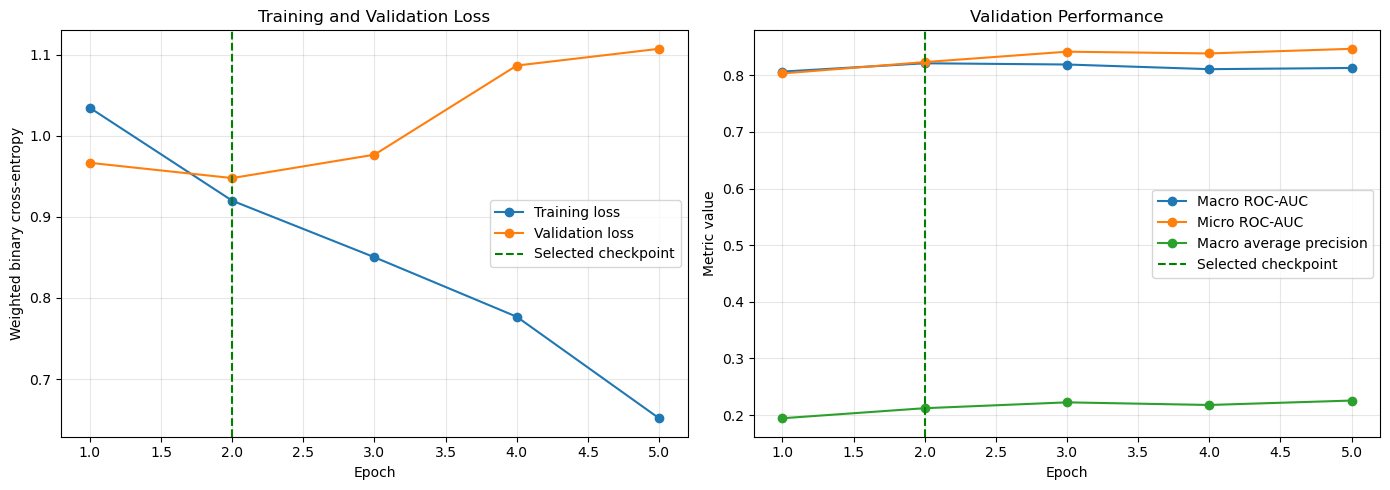

Chart saved: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/charts/resnet18_training_dynamics.png


In [28]:
import matplotlib.pyplot as plt

training_charts_path = (
    OUTPUTS_PATH / "charts"
)
training_charts_path.mkdir(
    parents=True,
    exist_ok=True,
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    training_history_df["epoch"],
    training_history_df["train_loss"],
    marker="o",
    label="Training loss",
)
axes[0].plot(
    training_history_df["epoch"],
    training_history_df["validation_loss"],
    marker="o",
    label="Validation loss",
)
axes[0].axvline(
    checkpoint_controller.best_epoch,
    color="green",
    linestyle="--",
    label="Selected checkpoint",
)
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Weighted binary cross-entropy")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    training_history_df["epoch"],
    training_history_df[
        "validation_macro_roc_auc"
    ],
    marker="o",
    label="Macro ROC-AUC",
)
axes[1].plot(
    training_history_df["epoch"],
    training_history_df[
        "validation_micro_roc_auc"
    ],
    marker="o",
    label="Micro ROC-AUC",
)
axes[1].plot(
    training_history_df["epoch"],
    training_history_df[
        "validation_macro_average_precision"
    ],
    marker="o",
    label="Macro average precision",
)
axes[1].axvline(
    checkpoint_controller.best_epoch,
    color="green",
    linestyle="--",
    label="Selected checkpoint",
)
axes[1].set_title("Validation Performance")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Metric value")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()

training_dynamics_chart = (
    training_charts_path
    / "resnet18_training_dynamics.png"
)

plt.savefig(
    training_dynamics_chart,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved: {training_dynamics_chart}")

### 6.3 Selected Checkpoint Validation

The selected checkpoint is reloaded independently from disk and evaluated against the complete validation partition. This confirms checkpoint integrity and separates final calibration from the model’s last training epoch.


In [29]:
selected_checkpoint = torch.load(
    BEST_CHECKPOINT_FILE,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(
    selected_checkpoint["model_state_dict"]
)

selected_validation_result = validate_model(
    model=model,
    data_loader=validation_loader,
    criterion=criterion,
    device=device,
    autocast_dtype=autocast_dtype,
    epoch_number="selected",
)

selected_metrics = selected_validation_result[
    "metrics"
]

print("SELECTED CHECKPOINT VALIDATION")
print("-" * 100)
print(f"{'Checkpoint epoch':<32}: {selected_checkpoint['epoch']}")
print(
    f"{'Validation loss':<32}: "
    f"{selected_validation_result['loss']:.4f}"
)
print(f"{'Macro ROC-AUC':<32}: {selected_metrics['macro_roc_auc']:.4f}")
print(f"{'Micro ROC-AUC':<32}: {selected_metrics['micro_roc_auc']:.4f}")
print(
    f"{'Macro average precision':<32}: "
    f"{selected_metrics['macro_average_precision']:.4f}"
)
print(
    f"{'Micro average precision':<32}: "
    f"{selected_metrics['micro_average_precision']:.4f}"
)
print(f"{'Macro F1 at 0.50':<32}: {selected_metrics['macro_f1']:.4f}")
print(f"{'Micro F1 at 0.50':<32}: {selected_metrics['micro_f1']:.4f}")
print(f"{'Hamming loss at 0.50':<32}: {selected_metrics['hamming_loss']:.4f}")

Validation epoch selected:   0%|          | 0/88 [00:00<?, ?it/s]

SELECTED CHECKPOINT VALIDATION
----------------------------------------------------------------------------------------------------
Checkpoint epoch                : 2
Validation loss                 : 0.9477
Macro ROC-AUC                   : 0.8210
Micro ROC-AUC                   : 0.8231
Macro average precision         : 0.2123
Micro average precision         : 0.2052
Macro F1 at 0.50                : 0.2024
Micro F1 at 0.50                : 0.2171
Hamming loss at 0.50            : 0.2841


### 6.4 Finding-Specific Threshold Calibration

Decision thresholds are calibrated independently for each finding using only the validation partition. The selected threshold maximizes validation F1 within a controlled range and is frozen before isolated test evaluation.


In [30]:
from sklearn.metrics import precision_recall_curve

MINIMUM_THRESHOLD = 0.05
MAXIMUM_THRESHOLD = 0.95

validation_targets = selected_validation_result[
    "targets"
]
validation_probabilities = (
    selected_validation_result["probabilities"]
)

threshold_records = []
calibrated_thresholds = np.zeros(
    NUM_LABELS,
    dtype=np.float32,
)

for label_id in range(NUM_LABELS):
    label_targets = validation_targets[
        :, label_id
    ]
    label_probabilities = validation_probabilities[
        :, label_id
    ]

    precision, recall, thresholds = (
        precision_recall_curve(
            label_targets,
            label_probabilities,
        )
    )

    valid_mask = (
        (thresholds >= MINIMUM_THRESHOLD)
        & (thresholds <= MAXIMUM_THRESHOLD)
    )

    valid_thresholds = thresholds[valid_mask]
    valid_precision = precision[:-1][valid_mask]
    valid_recall = recall[:-1][valid_mask]

    f1_values = (
        2
        * valid_precision
        * valid_recall
        / (
            valid_precision
            + valid_recall
            + 1e-12
        )
    )

    best_position = int(
        np.argmax(f1_values)
    )

    calibrated_thresholds[label_id] = (
        valid_thresholds[best_position]
    )

    threshold_records.append(
        {
            "Label ID": label_id,
            "Finding": LABEL_MAP[label_id],
            "Calibrated threshold": (
                calibrated_thresholds[label_id]
            ),
            "Validation precision": (
                valid_precision[best_position]
            ),
            "Validation recall": (
                valid_recall[best_position]
            ),
            "Validation F1": (
                f1_values[best_position]
            ),
        }
    )

threshold_calibration_df = pd.DataFrame(
    threshold_records
)

calibrated_metrics = calculate_multilabel_metrics(
    validation_targets,
    validation_probabilities,
    threshold=calibrated_thresholds,
)

display(
    threshold_calibration_df.style
    .format(
        {
            "Calibrated threshold": "{:.4f}",
            "Validation precision": "{:.4f}",
            "Validation recall": "{:.4f}",
            "Validation F1": "{:.4f}",
        }
    )
    .hide(axis="index")
)

print("\nCALIBRATED VALIDATION SUMMARY")
print("-" * 100)
print(
    f"{'Macro F1':<30}: "
    f"{calibrated_metrics['macro_f1']:.4f}"
)
print(
    f"{'Micro F1':<30}: "
    f"{calibrated_metrics['micro_f1']:.4f}"
)
print(
    f"{'Hamming loss':<30}: "
    f"{calibrated_metrics['hamming_loss']:.4f}"
)

Label ID,Finding,Calibrated threshold,Validation precision,Validation recall,Validation F1
0,atelectasis,0.6797,0.2832,0.5165,0.3658
1,cardiomegaly,0.8438,0.2747,0.5333,0.3626
2,effusion,0.6758,0.3960,0.6780,0.5000
3,infiltration,0.5977,0.3116,0.5208,0.3899
4,mass,0.8672,0.3538,0.3408,0.3472
5,nodule,0.8125,0.2070,0.3067,0.2472
6,pneumonia,0.7695,0.0526,0.2707,0.0880
7,pneumothorax,0.8281,0.2996,0.4940,0.3730
8,consolidation,0.7461,0.1476,0.4720,0.2248
9,edema,0.8789,0.1278,0.5700,0.2088



CALIBRATED VALIDATION SUMMARY
----------------------------------------------------------------------------------------------------
Macro F1                      : 0.2947
Micro F1                      : 0.3429
Hamming loss                  : 0.0949


## 7. Versioned Model Packaging

### 7.1 Inference Bundle Export

The selected checkpoint is packaged with its label map, calibrated thresholds, preprocessing contract, validation metrics, MLflow lineage and interpretation safeguards. The resulting bundle is the controlled source for evaluation, explainability and API inference.


In [31]:
from datetime import datetime, timezone

MODEL_VERSION = "resnet18-chestmnist-v1"

model_bundle_path = (
    MODEL_PATH / MODEL_VERSION
)
model_bundle_path.mkdir(
    parents=True,
    exist_ok=True,
)

model_weights_file = (
    model_bundle_path
    / "model_state_dict.pt"
)
model_metadata_file = (
    model_bundle_path
    / "model_metadata.yaml"
)
threshold_metrics_file = (
    training_metrics_path
    / "validation_threshold_calibration.csv"
)

portable_state_dict = {
    parameter_name: parameter.detach().cpu()
    for parameter_name, parameter
    in model.state_dict().items()
}

torch.save(
    portable_state_dict,
    model_weights_file,
)

threshold_calibration_df.to_csv(
    threshold_metrics_file,
    index=False,
)

model_metadata = {
    "model": {
        "version": MODEL_VERSION,
        "architecture": "resnet18",
        "pretrained_weights": (
            training_config["pretrained_weights"]
        ),
        "output_labels": NUM_LABELS,
        "checkpoint_epoch": int(
            selected_checkpoint["epoch"]
        ),
        "created_at_utc": datetime.now(
            timezone.utc
        ).isoformat(),
    },
    "lineage": {
        "dataset": "ChestMNIST",
        "dataset_checksum_md5": (
            dataset_settings["checksum_md5"]
        ),
        "mlflow_experiment": (
            MLFLOW_EXPERIMENT_NAME
        ),
        "mlflow_run_id": MLFLOW_RUN_ID,
    },
    "input_contract": {
        "shape": [None, 3, IMAGE_SIZE, IMAGE_SIZE],
        "source_format": "grayscale chest X-ray",
        "grayscale_to_rgb": True,
        "normalization": (
            preprocessing_settings[
                "normalization"
            ]
        ),
    },
    "output_contract": {
        "shape": [None, NUM_LABELS],
        "activation": "sigmoid",
        "labels": LABEL_MAP,
        "thresholds": {
            LABEL_MAP[label_id]: float(
                calibrated_thresholds[label_id]
            )
            for label_id in range(NUM_LABELS)
        },
    },
    "validation_metrics": {
        "macro_roc_auc": selected_metrics[
            "macro_roc_auc"
        ],
        "micro_roc_auc": selected_metrics[
            "micro_roc_auc"
        ],
        "macro_average_precision": (
            selected_metrics[
                "macro_average_precision"
            ]
        ),
        "micro_average_precision": (
            selected_metrics[
                "micro_average_precision"
            ]
        ),
        "calibrated_macro_f1": (
            calibrated_metrics["macro_f1"]
        ),
        "calibrated_micro_f1": (
            calibrated_metrics["micro_f1"]
        ),
        "calibrated_hamming_loss": (
            calibrated_metrics["hamming_loss"]
        ),
    },
    "interpretation_policy": (
        dataset_config[
            "interpretation_policy"
        ]
    ),
}

with model_metadata_file.open(
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        model_metadata,
        file,
        sort_keys=False,
        default_flow_style=False,
    )

mlflow_client.log_artifact(
    MLFLOW_RUN_ID,
    str(model_weights_file),
    artifact_path="model_bundle",
)
mlflow_client.log_artifact(
    MLFLOW_RUN_ID,
    str(model_metadata_file),
    artifact_path="model_bundle",
)
mlflow_client.log_artifact(
    MLFLOW_RUN_ID,
    str(threshold_metrics_file),
    artifact_path="validation",
)

del portable_state_dict

print("VERSIONED MODEL BUNDLE")
print("-" * 100)
print(f"{'Model version':<30}: {MODEL_VERSION}")
print(f"{'Bundle directory':<30}: {model_bundle_path}")
print(f"{'Weights available':<30}: {model_weights_file.exists()}")
print(f"{'Metadata available':<30}: {model_metadata_file.exists()}")
print(f"{'Thresholds available':<30}: {threshold_metrics_file.exists()}")

VERSIONED MODEL BUNDLE
----------------------------------------------------------------------------------------------------
Model version                 : resnet18-chestmnist-v1
Bundle directory              : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/models/resnet18-chestmnist-v1
Weights available             : True
Metadata available            : True
Thresholds available          : True


## 8. Model Development Readiness Gate

The model-development lifecycle is validated before the untouched test partition is accessed. The readiness gate confirms checkpoint integrity, experiment lineage, calibrated decision thresholds and availability of the complete inference bundle.


In [32]:
tracked_run = mlflow_client.get_run(
    MLFLOW_RUN_ID
)

model_readiness_checks = {
    "Best checkpoint available": (
        BEST_CHECKPOINT_FILE.exists()
    ),
    "Training history available": (
        training_history_file.exists()
    ),
    "Training chart available": (
        training_dynamics_chart.exists()
    ),
    "Memory-mapped arrays validated": all(
        memmap_validation.values()
    ),
    "Selected checkpoint is epoch 2": (
        selected_checkpoint["epoch"]
        == checkpoint_controller.best_epoch
    ),
    "Calibrated thresholds complete": (
        len(calibrated_thresholds)
        == NUM_LABELS
        and np.isfinite(
            calibrated_thresholds
        ).all()
    ),
    "Versioned weights available": (
        model_weights_file.exists()
    ),
    "Versioned metadata available": (
        model_metadata_file.exists()
    ),
    "MLflow run completed": (
        tracked_run.info.status
        == "FINISHED"
    ),
}

failed_model_checks = [
    check_name
    for check_name, passed
    in model_readiness_checks.items()
    if not passed
]

print("MODEL DEVELOPMENT READINESS")
print("-" * 100)

for check_name, passed in model_readiness_checks.items():
    print(
        f"{check_name:<42}: "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("\nFINAL STATUS")
print("-" * 100)
print(
    "READY FOR ISOLATED TEST EVALUATION"
    if not failed_model_checks
    else (
        "NOT READY — Failed checks: "
        + ", ".join(failed_model_checks)
    )
)

MODEL DEVELOPMENT READINESS
----------------------------------------------------------------------------------------------------
Best checkpoint available                 : PASS
Training history available                : PASS
Training chart available                  : PASS
Memory-mapped arrays validated            : PASS
Selected checkpoint is epoch 2            : PASS
Calibrated thresholds complete            : PASS
Versioned weights available               : PASS
Versioned metadata available              : PASS
MLflow run completed                      : PASS

FINAL STATUS
----------------------------------------------------------------------------------------------------
READY FOR ISOLATED TEST EVALUATION
